## 세종시 주차장 현황 분석 `.ipynb`

In [2]:
import pandas as pd

data_path = "../resources/parking_lot.csv"

df = pd.read_csv(data_path, encoding="CP949")
print(df.head())

    적재_연월   주차장 명칭 주차장 구분자 정보 주차장 유형 구분자 정보        주차장 위치 도로명주소정보  \
0  202603     나성노상         공영            노상       세종특별자치시 노을1로 16   
1  202603     도담노상         공영            노상     세종특별자치시 보듬3로 8-20   
2  202603     신안리1         공영            노외   세종특별자치시 조치원읍 장안길 14   
3  202603      원리1         공영            노상  세종특별자치시 조치원읍 으뜸길 122   
4  202603  조치원주차타워         공영            노외   세종특별자치시 조치원읍 새내로 99   

  주차장 위치 지번주소정보  주차장 주차 구획수 주차장 부제 시행 구분자 정보    주차장 운영요일 주차장 평일 운영시작시각  ...  \
0             -          33              미시행          평일          8:00  ...   
1             -          13              미시행          평일          8:00  ...   
2             -          49              미시행  평일+토요일+공휴일          7:00  ...   
3             -          36              미시행  평일+토요일+공휴일          7:00  ...   
4             -         200              미시행  평일+토요일+공휴일          8:00  ...   

  주차장 추가 단위요금 주차장 1일 주차권 요금 적용시간 주차장 1일 주차권 요금 주차장 월 정기권 요금 주차장 결제 방법 정보  \
0         500                  0  

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   적재_연월               60 non-null     int64  
 1   주차장 명칭              60 non-null     object 
 2   주차장 구분자 정보          60 non-null     object 
 3   주차장 유형 구분자 정보       60 non-null     object 
 4   주차장 위치 도로명주소정보      60 non-null     object 
 5   주차장 위치 지번주소정보       60 non-null     object 
 6   주차장 주차 구획수          60 non-null     int64  
 7   주차장 부제 시행 구분자 정보    60 non-null     object 
 8   주차장 운영요일            60 non-null     object 
 9   주차장 평일 운영시작시각       60 non-null     object 
 10  주차장 평일 운영종료시각       60 non-null     object 
 11  주차장 토요일 운영시작시각      60 non-null     object 
 12  주차장 토요일 운영종료시각      60 non-null     object 
 13  주차장 공휴일 운영시작시각      60 non-null     object 
 14  주차장 공휴일 운영종료시각      60 non-null     object 
 15  주차장 요금 유무 정보        60 non-null     object 
 16  주차장 주차 기본시

### 데이터
|열 명칭|사용 여부|
|------|--------|
|적재_연월|X|
|주차장 명칭|O|
|주차장 구분자 정보|X|
|주차장 유형 구분자 정보|X|
|주차장 위치 도로명주소정보|O|
|주차장 위치 지번주소정보|X|
|주차장 주차 구획수|O|
|주차장 부제 시행 구분자 정보|X|
|주차장 운영요일|O|
|주차장 평일 운영시작시각|O|
|주차장 평일 운영종료시각|O|
|주차장 토요일 운영시작시각|O|
|주차장 토요일 운영종료시각|O|
|주차장 일요일 운영시작시각|O|
|주차장 일요일 운영종료시각|O|
|주차장 요금 유무 정보|O|
|주차장 주차 기본시간|O|
|주차장 주차 기본요금|O|
|주차장 추가 단위시간|O|
|주차장 추가 단위요금|O|
|주차장 1일 주차권 요금 적용시간|X|
|주차장 1일 주차권 요금|O|
|주차장 월 정기권 요금|O|
|주차장 결제 방법 정보|X|
|주차장 관리기관명|X|
|주차장 관리기관 전화번호|X|
|주차장 위치 위도 좌표정보|O|
|주차장 위치 경도 좌표정보|O|
|주차장 데이터 기준일자|X|


In [4]:
df_cleaned = df[[
    '주차장 명칭',
    '주차장 위치 도로명주소정보',
    '주차장 주차 구획수',
    '주차장 위치 위도 좌표정보',
    '주차장 위치 경도 좌표정보'
]].copy()
df_cleaned.head()

,주차장 명칭,주차장 위치 도로명주소정보,주차장 주차 구획수,주차장 위치 위도 좌표정보,주차장 위치 경도 좌표정보
0,나성노상,세종특별자치시 노을1로 16,33,36.480855,127.260618
1,도담노상,세종특별자치시 보듬3로 8-20,13,36.514302,127.258607
2,신안리1,세종특별자치시 조치원읍 장안길 14,49,36.599862,127.300027
3,원리1,세종특별자치시 조치원읍 으뜸길 122,36,36.596981,127.297696
4,조치원주차타워,세종특별자치시 조치원읍 새내로 99,200,36.600636,127.297719


In [5]:
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point

df_cleaned['geometry'] = df_cleaned.apply(
    lambda x: Point(x['주차장 위치 경도 좌표정보'], x['주차장 위치 위도 좌표정보']),
    axis=1
)
geo_df = GeoDataFrame(df_cleaned, geometry='geometry', crs='EPSG:4326')
geo_df.head()

,주차장 명칭,주차장 위치 도로명주소정보,주차장 주차 구획수,주차장 위치 위도 좌표정보,주차장 위치 경도 좌표정보,geometry
0,나성노상,세종특별자치시 노을1로 16,33,36.480855,127.260618,POINT (127.26062 36.48086)
1,도담노상,세종특별자치시 보듬3로 8-20,13,36.514302,127.258607,POINT (127.25861 36.5143)
2,신안리1,세종특별자치시 조치원읍 장안길 14,49,36.599862,127.300027,POINT (127.30003 36.59986)
3,원리1,세종특별자치시 조치원읍 으뜸길 122,36,36.596981,127.297696,POINT (127.2977 36.59698)
4,조치원주차타워,세종특별자치시 조치원읍 새내로 99,200,36.600636,127.297719,POINT (127.29772 36.60064)


In [6]:
geo_shp = gpd.read_file('../resources/sejong-geodata/bnd_dong.shp', encoding='utf-8')
geo_shp = geo_shp.set_crs(epsg=5179, allow_override=True).to_crs(epsg=4326)

dong = gpd.sjoin(geo_df, geo_shp, how='left', predicate='within')
dong.head()

,주차장 명칭,주차장 위치 도로명주소정보,주차장 주차 구획수,주차장 위치 위도 좌표정보,주차장 위치 경도 좌표정보,geometry,index_right,BASE_DATE,ADM_CD,ADM_NM
0,나성노상,세종특별자치시 노을1로 16,33,36.480855,127.260618,POINT (127.26062 36.48086),19,20250630,29010610,한솔동
1,도담노상,세종특별자치시 보듬3로 8-20,13,36.514302,127.258607,POINT (127.25861 36.5143),12,20250630,29010514,도담동
2,신안리1,세종특별자치시 조치원읍 장안길 14,49,36.599862,127.300027,POINT (127.30003 36.59986),0,20250630,29010110,조치원읍
3,원리1,세종특별자치시 조치원읍 으뜸길 122,36,36.596981,127.297696,POINT (127.2977 36.59698),0,20250630,29010110,조치원읍
4,조치원주차타워,세종특별자치시 조치원읍 새내로 99,200,36.600636,127.297719,POINT (127.29772 36.60064),0,20250630,29010110,조치원읍


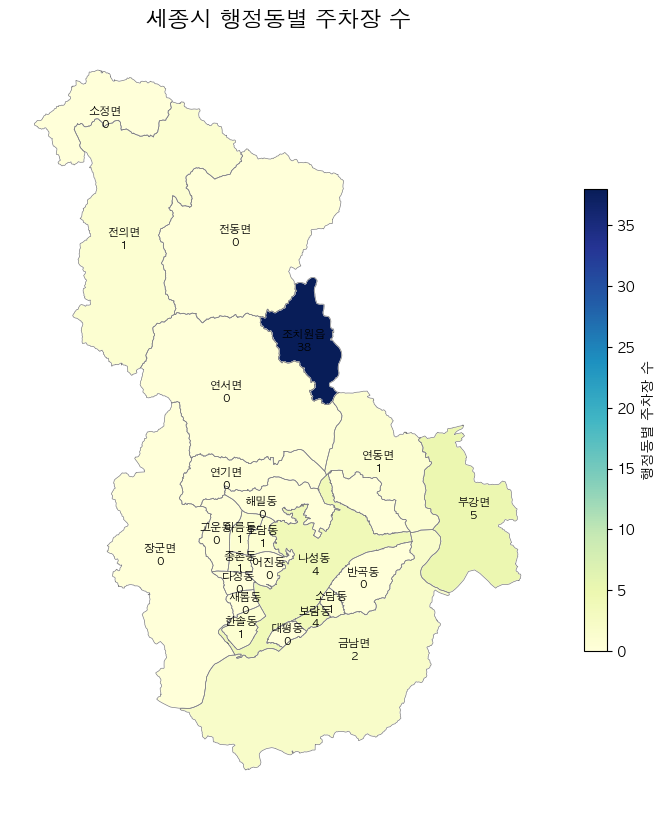

,ADM_NM,parking_lot_count
9,조치원읍,38
4,부강면,5
1,나성동,4
3,보람동,4
0,금남면,2
2,도담동,1
5,소담동,1
6,아름동,1
7,연동면,1
8,전의면,1


In [7]:
# 행정동별 주차장 수를 세종시 지도에 시각화하기
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from pathlib import Path

font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_path = Path('C:/Windows/Fonts/malgun.ttf')
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    rc('font', family=font_manager.FontProperties(fname=str(font_path)).get_name())
else:
    for font_name in font_candidates:
        if font_name in available_fonts:
            rc('font', family=font_name)
            break
plt.rcParams['axes.unicode_minus'] = False

dong_counts = (
    dong.groupby('ADM_NM')
    .size()
    .reset_index(name='parking_lot_count')
)

parking_count_map = geo_shp.merge(dong_counts, on='ADM_NM', how='left')
parking_count_map['parking_lot_count'] = parking_count_map['parking_lot_count'].fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 10))
parking_count_map.plot(
    column='parking_lot_count',
    cmap='YlGnBu',
    linewidth=0.8,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': '행정동별 주차장 수', 'shrink': 0.6},
    ax=ax
)
parking_count_map.boundary.plot(ax=ax, linewidth=0.5, color='gray')

for _, row in parking_count_map.iterrows():
    point = row.geometry.representative_point()
    label = f"{row['ADM_NM']}\n{row['parking_lot_count']:,}"
    ax.text(point.x, point.y, label, fontsize=8, ha='center', va='center')

ax.set_title('세종시 행정동별 주차장 수', fontsize=16)
ax.set_axis_off()
plt.show()

dong_counts.sort_values('parking_lot_count', ascending=False)


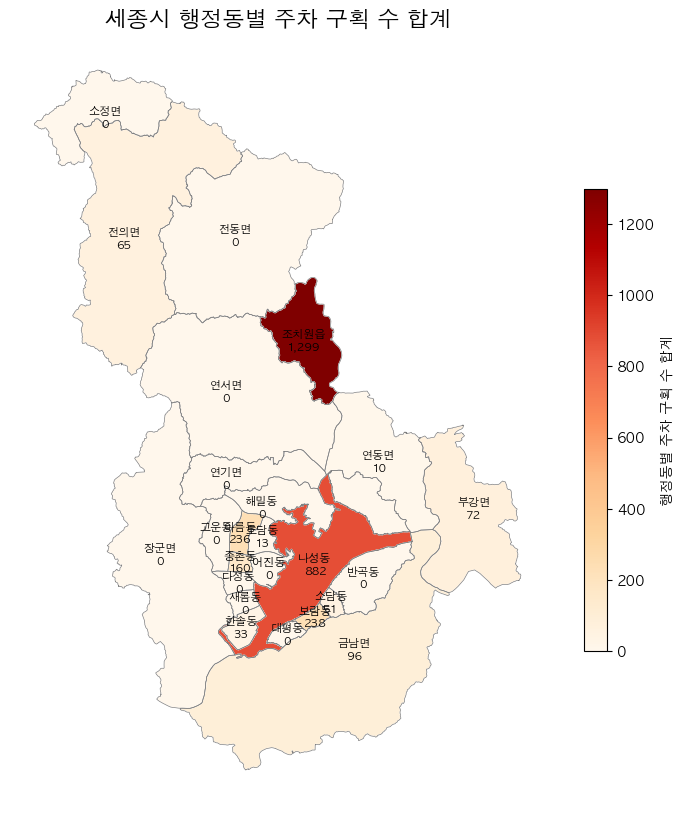

,ADM_NM,parking_space_count
9,조치원읍,1299
1,나성동,882
3,보람동,238
6,아름동,236
10,종촌동,160
0,금남면,96
4,부강면,72
8,전의면,65
5,소담동,51
11,한솔동,33


In [8]:
# 행정동별 주차장 구획 수를 합계하여 세종시 지도에 시각화하기
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from pathlib import Path

font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_path = Path('C:/Windows/Fonts/malgun.ttf')
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    rc('font', family=font_manager.FontProperties(fname=str(font_path)).get_name())
else:
    for font_name in font_candidates:
        if font_name in available_fonts:
            rc('font', family=font_name)
            break
plt.rcParams['axes.unicode_minus'] = False

dong['주차장 주차 구획수'] = pd.to_numeric(
    dong['주차장 주차 구획수'],
    errors='coerce'
).fillna(0)

dong_spaces = (
    dong.groupby('ADM_NM')['주차장 주차 구획수']
    .sum()
    .reset_index(name='parking_space_count')
)
dong_spaces['parking_space_count'] = dong_spaces['parking_space_count'].astype(int)

parking_space_map = geo_shp.merge(dong_spaces, on='ADM_NM', how='left')
parking_space_map['parking_space_count'] = parking_space_map['parking_space_count'].fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 10))
parking_space_map.plot(
    column='parking_space_count',
    cmap='OrRd',
    linewidth=0.8,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': '행정동별 주차 구획 수 합계', 'shrink': 0.6},
    ax=ax
)
parking_space_map.boundary.plot(ax=ax, linewidth=0.5, color='gray')

for _, row in parking_space_map.iterrows():
    point = row.geometry.representative_point()
    label = f"{row['ADM_NM']}\n{row['parking_space_count']:,}"
    ax.text(point.x, point.y, label, fontsize=8, ha='center', va='center')

ax.set_title('세종시 행정동별 주차 구획 수 합계', fontsize=16)
ax.set_axis_off()
plt.show()

dong_spaces.sort_values('parking_space_count', ascending=False)


In [10]:
# 행정동별 주차장 수 + 주차 구획 수 합치기
parking_summary = pd.merge(
    dong_counts,
    dong_spaces,
    on='ADM_NM',
    how='outer'
)

# 컬럼명 한글로 변경
parking_summary = parking_summary.rename(columns={
    'ADM_NM': '지역',
    'parking_lot_count': '주차장수',
    'parking_space_count': '주차구획수'
})

# 결측치 처리
parking_summary[['주차장수', '주차구획수']] = parking_summary[['주차장수', '주차구획수']].fillna(0).astype(int)

# 주차구획수 기준 내림차순 정렬
parking_summary = parking_summary.sort_values('주차구획수', ascending=False)

# CSV 파일로 저장
parking_summary.to_csv(
    '../resources/parking_summary.csv',
    index=False,
    encoding='utf-8-sig'
)

parking_summary

,지역,주차장수,주차구획수
9,조치원읍,38,1299
1,나성동,4,882
3,보람동,4,238
6,아름동,1,236
10,종촌동,1,160
0,금남면,2,96
4,부강면,5,72
8,전의면,1,65
5,소담동,1,51
11,한솔동,1,33
